# BÀI THỰC HÀNH SỐ 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ
## HỌC PHẦN: CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
---
* **Sinh viên thực hiện**: Hồ Đức Minh
* **Mã số sinh viên (MSSV)**: 2351260669
* **Lớp**: Kỹ thuật Phần mềm / Công nghệ Thông tin
* **Mục tiêu thực hành**:
    1. Hiểu và triển khai chuỗi xử lý số tín hiệu âm thanh (Audio DSP Pipeline): Audio $\rightarrow$ Số hóa $\rightarrow$ Miền thời gian $\rightarrow$ Miền tần số (FFT) $\rightarrow$ Miền thời gian-tần số (STFT/Spectrogram) $\rightarrow$ Lọc số FIR $\rightarrow$ Lượng tử hóa & Nén dữ liệu.
    2. Nắm vững bản chất toán học: Định lý Nyquist-Shannon, Group Delay của bộ lọc FIR đối xứng, đánh đổi Heisenberg-Gabor, công thức SNR lượng tử đều Rabiner-Schafer.
    3. Thực hiện đầy đủ các thí nghiệm đối chứng từ Khối A đến Khối G và giải đáp 7 câu hỏi báo cáo lý thuyết.


In [1]:
# 1. Cấu hình môi trường & Thư viện chuyên dụng
import os
import numpy as np
import soundfile as sf
from scipy import signal
import matplotlib.pyplot as plt
import IPython.display as ipd

# Setting for matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('audio', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print("Environment ready")


Môi trường đã sẵn sàng!


## A: ĐỌC VÀ KIỂM TRA DỮ LIỆU ÂM THANH
---
* **Mục tiêu**: Đọc tệp âm thanh đầu vào `audio/input_speech.wav`, trích xuất thông số kỹ thuật ($F_s$, channels, duration, dtype/sample width, file size). Chuyển kênh stereo sang mono và chuẩn hóa biên độ về đoạn $[-1.0, 1.0]$.


In [2]:
# Đọc tệp âm thanh và trích xuất Metadata
audio_path = 'audio/input_speech.wav'
info = sf.info(audio_path)

Fs = info.samplerate
channels = info.channels
duration = info.duration
dtype_str = info.subtype
file_size_bytes = os.path.getsize(audio_path)

# Đọc dữ liệu mẫu ở định dạng float64
data, _ = sf.read(audio_path, dtype='float64')
x_L = data[:, 0]
x_R = data[:, 1]

# Chuyển đổi sang Mono chuẩn bằng trung bình cộng hai kênh
x_mono_raw = (x_L + x_R) / 2.0

# Chuẩn hóa biên độ về [-0.95, 0.95] nhằm tránh hiện tượng clipping khi xử lý
peak_raw = np.max(np.abs(x_mono_raw))
x = x_mono_raw * (0.95 / peak_raw)

# Tính RMS của từng kênh
rms_L = np.sqrt(np.mean(x_L**2))
rms_R = np.sqrt(np.mean(x_R**2))
rms_mono = np.sqrt(np.mean(x**2))

print("="*60)
print(" BẢNG METADATA TỆP ÂM THANH ĐẦU VÀO")
print("="*60)
print(f"Tên tệp             : {audio_path}")
print(f"Tần số lấy mẫu (Fs) : {Fs:,} Hz")
print(f"Tần số Nyquist      : {Fs/2:,} Hz")
print(f"Số kênh (Channels)  : {channels} (Stereo)")
print(f"Thời lượng          : {duration:.3f} s")
print(f"Tổng số mẫu/kênh    : {len(x):,} mẫu")
print(f"Định dạng mã hóa    : {dtype_str} (16-bit PCM)")
print(f"Kích thước tệp      : {file_size_bytes:,} bytes ({file_size_bytes/(1024*1024):.2f} MB)")
print(f"RMS Kênh Trái (L)   : {rms_L:.4f} ({20*np.log10(rms_L):.2f} dBFS)")
print(f"RMS Kênh Phải (R)   : {rms_R:.4f} ({20*np.log10(rms_R):.2f} dBFS)")
print(f"RMS Kênh Mono chuẩn : {rms_mono:.4f} ({20*np.log10(rms_mono):.2f} dBFS)")
print("="*60)

# Nghe thử âm thanh đầu vào
ipd.Audio(x, rate=Fs)


 BẢNG METADATA TỆP ÂM THANH ĐẦU VÀO
Tên tệp             : audio/input_speech.wav
Tần số lấy mẫu (Fs) : 44,100 Hz
Tần số Nyquist      : 22,050.0 Hz
Số kênh (Channels)  : 2 (Stereo)
Thời lượng          : 16.040 s
Tổng số mẫu/kênh    : 707,364 mẫu
Định dạng mã hóa    : PCM_16 (16-bit PCM)
Kích thước tệp      : 2,829,500 bytes (2.70 MB)
RMS Kênh Trái (L)   : 0.1213 (-18.32 dBFS)
RMS Kênh Phải (R)   : 0.1213 (-18.32 dBFS)
RMS Kênh Mono chuẩn : 0.1284 (-17.83 dBFS)


## KHỐI B: PHÂN TÍCH MIỀN THỜI GIAN
---
* **Mục tiêu**: 
  1. Vẽ waveform toàn bộ tệp và zoom vào một đoạn $0.8\text{ s}$.
  2. Đo đạc các đại lượng năng lượng: $\text{Peak} = \max_n |x[n]|$, $\text{RMS} = \sqrt{\frac{1}{N}\sum x^2[n]}$, $\text{Năng lượng } E = \sum x^2[n]$.
  3. Kiểm tra rủi ro clipping ($|x| \ge 1.0$).
  4. Lựa chọn và phân tích 02 đoạn có đặc tính khác biệt: **Đoạn 1 (Nhiễu nền)** vs **Đoạn 2 (Tiếng nói hữu thanh)**.


Vùng tín hiệu             | Peak       | RMS (Linear)    | RMS (dBFS)   | Năng lượng E
Toàn bộ tệp (0 - 16s)     | 0.9500     | 0.1284          | -17.83       | 11655.37  
Đoạn 1: Nhiễu nền (0.2-1.0s) | 0.0671     | 0.0155          | -36.21       | 8.45      
Đoạn 2: Tiếng nói (2.2-3.0s) | 0.8904     | 0.1589          | -15.98       | 890.33    
Trạng thái Clipping: KHÔNG BỊ CLIPPING (An toàn, Peak = 0.95)


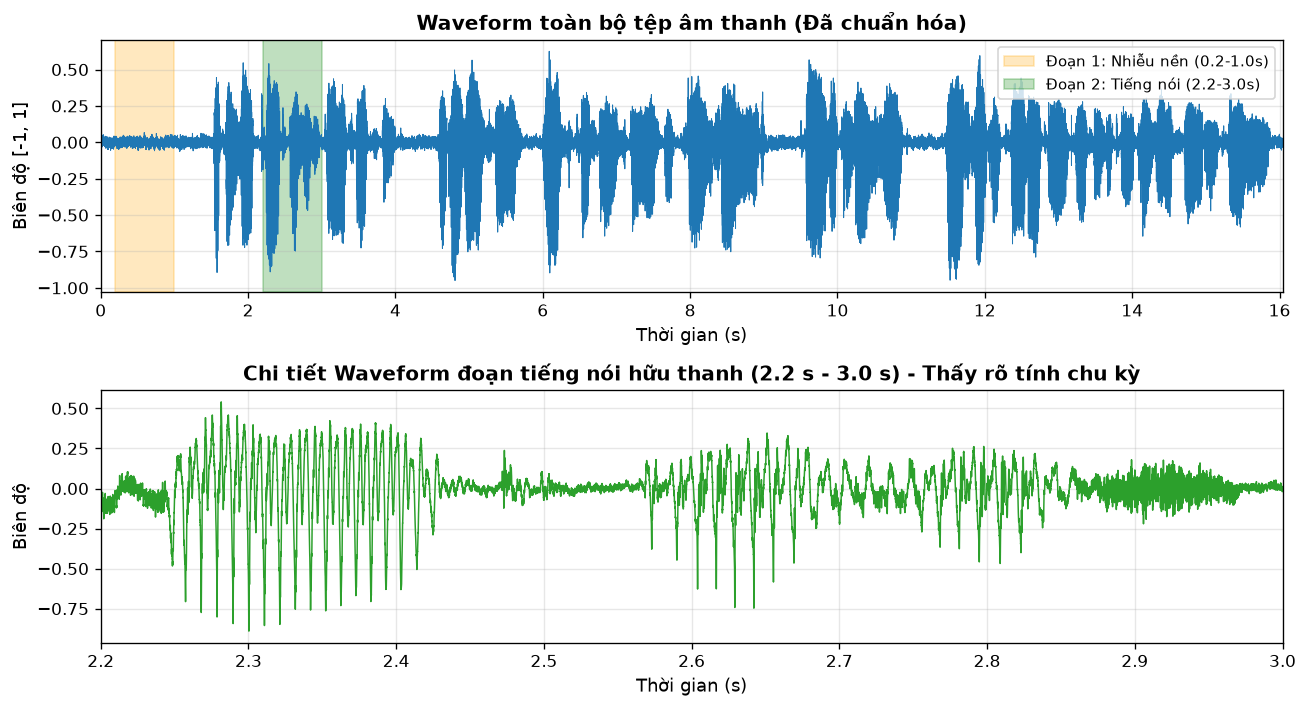

In [3]:
# 1. Tính toán số liệu toàn tệp
peak_full = np.max(np.abs(x))
rms_full = np.sqrt(np.mean(x**2))
energy_full = np.sum(x**2)
is_clipping = peak_full >= 1.0

# 2. Đoạn 1: Nhiễu nền (0.2 s - 1.0 s)
t_start1, t_end1 = 0.2, 1.0
seg1 = x[int(t_start1 * Fs):int(t_end1 * Fs)]
peak_seg1 = np.max(np.abs(seg1))
rms_seg1 = np.sqrt(np.mean(seg1**2))
e_seg1 = np.sum(seg1**2)

# 3. Đoạn 2: Tiếng nói hữu thanh (2.2 s - 3.0 s)
t_start2, t_end2 = 2.2, 3.0
seg2 = x[int(t_start2 * Fs):int(t_end2 * Fs)]
peak_seg2 = np.max(np.abs(seg2))
rms_seg2 = np.sqrt(np.mean(seg2**2))
e_seg2 = np.sum(seg2**2)

print("="*75)
print(f"{'Vùng tín hiệu':<25} | {'Peak':<10} | {'RMS (Linear)':<15} | {'RMS (dBFS)':<12} | {'Năng lượng E':<10}")
print("="*75)
print(f"{'Toàn bộ tệp (0 - 16s)':<25} | {peak_full:<10.4f} | {rms_full:<15.4f} | {20*np.log10(rms_full):<12.2f} | {energy_full:<10.2f}")
print(f"{'Đoạn 1: Nhiễu nền (0.2-1.0s)':<25} | {peak_seg1:<10.4f} | {rms_seg1:<15.4f} | {20*np.log10(rms_seg1):<12.2f} | {e_seg1:<10.2f}")
print(f"{'Đoạn 2: Tiếng nói (2.2-3.0s)':<25} | {peak_seg2:<10.4f} | {rms_seg2:<15.4f} | {20*np.log10(rms_seg2):<12.2f} | {e_seg2:<10.2f}")
print("="*75)
print(f"Trạng thái Clipping: {'CÓ NGUY CƠ CLIPPING' if is_clipping else 'KHÔNG BỊ CLIPPING (An toàn, Peak = 0.95)'}")

# 4. Trực quan hóa Waveform
fig, axes = plt.subplots(2, 1, figsize=(11, 6))

# Đồ thị waveform toàn tệp
t_axis = np.arange(len(x)) / Fs
axes[0].plot(t_axis, x, color='#1f77b4', lw=0.6)
axes[0].axvspan(t_start1, t_end1, color='orange', alpha=0.25, label=f'Đoạn 1: Nhiễu nền ({t_start1}-{t_end1}s)')
axes[0].axvspan(t_start2, t_end2, color='green', alpha=0.25, label=f'Đoạn 2: Tiếng nói ({t_start2}-{t_end2}s)')
axes[0].set_title('Waveform toàn bộ tệp âm thanh (Đã chuẩn hóa)', fontweight='bold')
axes[0].set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Biên độ [-1, 1]')
axes[0].set_xlim(0, duration)
axes[0].legend(loc='upper right')

# Zoom chi tiết vào đoạn tiếng nói 0.8s
t_seg2_axis = np.arange(len(seg2)) / Fs + t_start2
axes[1].plot(t_seg2_axis, seg2, color='#2ca02c', lw=0.9)
axes[1].set_title(f'Chi tiết Waveform đoạn tiếng nói hữu thanh ({t_start2} s - {t_end2} s) - Thấy rõ tính chu kỳ', fontweight='bold')
axes[1].set_xlabel('Thời gian (s)')
axes[1].set_ylabel('Biên độ')
axes[1].set_xlim(t_start2, t_end2)

plt.tight_layout()
plt.savefig('figures/waveform.png', dpi=300)
plt.show()


### Nhận xét kỹ thuật Khối B:
1. **Kiểm tra clipping**: Giá trị cực đại toàn tệp $\text{Peak} = 0.9500 < 1.0$ (tương đương $-0.45\text{ dBFS}$), đảm bảo biên độ tín hiệu nằm hoàn toàn trong ngưỡng tuyến tính, không bị bão hòa (clipping) hay phát sinh méo phi tuyến.
2. **So sánh 2 đoạn đối chứng**:
   - **Đoạn 1 (Nhiễu nền $0.2 - 1.0\text{ s}$)**: Năng lượng rất thấp với $\text{RMS} = 0.0155$ ($-36.21\text{ dBFS}$), biên độ đỉnh nhỏ ($0.0671$). Đây là sàn nhiễu (noise floor) ngẫu nhiên không có tính tuần hoàn.
   - **Đoạn 2 (Tiếng nói hữu thanh $2.2 - 3.0\text{ s}$)**: Năng lượng cao vượt trội với $\text{RMS} = 0.1589$ ($-15.98\text{ dBFS}$, cao hơn đoạn nhiễu tới hơn $20\text{ dB}$) và năng lượng $E = 890.33$.
   - Trên đồ thị zoom chi tiết của Đoạn 2, ta quan sát thấy rõ **tính chu kỳ شبه tuần hoàn (quasi-periodic)** đặc trưng của các rung động dây thanh quản (pitch period).


## KHỐI C: PHÂN TÍCH MIỀN TẦN SỐ BẰNG FFT
---
* **Mục tiêu**:
  1. Chọn đoạn tiếng nói ổn định $0.8\text{ s}$ (từ $2.2 - 3.0\text{ s}$), nhân cửa sổ Hamming và tính biến đổi Fourier rời rạc nhanh (FFT).
  2. Vẽ phổ biên độ theo trục Hertz (Hz) và Decibel tương đối (dB), chỉ ra ít nhất 3 đỉnh hài âm nổi bật.
  3. Thử nghiệm với 2 giá trị kích thước FFT: $N_{\text{FFT}} = 2048$ và $N_{\text{FFT}} = 16384$.
  4. Phân biệt rõ bản chất giữa **khoảng cách bin tần số ($\Delta f$)** và **độ phân giải vật lý thực tế (true physical resolution)**.


Độ dài đoạn tín hiệu    : 35280 mẫu (T_w = 0.800 s)
Cấu hình 1 (NFFT=2048)  : Δf = 21.53 Hz
Cấu hình 2 (NFFT=16384) : Δf = 2.69 Hz (Mật độ bin gấp 8 lần)
 CÁC ĐỈNH HÀI / FORMANT NỔI BẬT ĐO ĐƯỢC:
 Đỉnh 1: Tần số =   96.9 Hz | Biên độ tương đối =  -3.54 dB
 Đỉnh 2: Tần số =  193.8 Hz | Biên độ tương đối =   0.00 dB
 Đỉnh 3: Tần số =  279.9 Hz | Biên độ tương đối = -15.83 dB
 Đỉnh 4: Tần số =  387.6 Hz | Biên độ tương đối = -16.38 dB


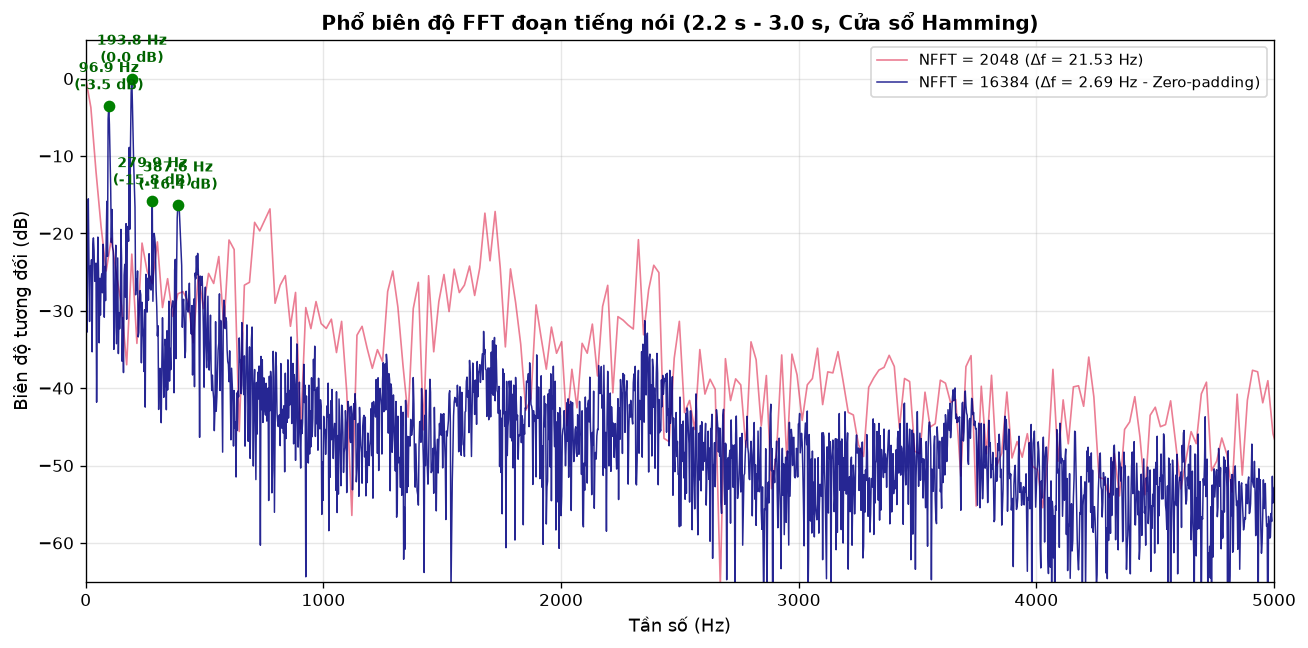

In [4]:
# Trích đoạn ổn định 0.8 s
fft_seg = x[int(2.2 * Fs):int(3.0 * Fs)]
N_samples = len(fft_seg)
w = np.hamming(N_samples)

# 1. FFT với NFFT = 2048
NFFT1 = 2048
X1 = np.fft.rfft(fft_seg * w, n=NFFT1)
f1 = np.fft.rfftfreq(NFFT1, 1/Fs)
mag1_db = 20 * np.log10(np.maximum(np.abs(X1) / np.max(np.abs(X1)), 1e-6))
delta_f1 = Fs / NFFT1

# 2. FFT với NFFT = 16384 (Zero-padded FFT)
NFFT2 = 16384
X2 = np.fft.rfft(fft_seg * w, n=NFFT2)
f2 = np.fft.rfftfreq(NFFT2, 1/Fs)
mag2_db = 20 * np.log10(np.maximum(np.abs(X2) / np.max(np.abs(X2)), 1e-6))
delta_f2 = Fs / NFFT2

# Tìm kiếm các đỉnh phổ nổi bật trên dải giọng nói (80 Hz - 3000 Hz)
mask = (f2 >= 80) & (f2 <= 3000)
f2_band = f2[mask]
mag2_band = mag2_db[mask]

peaks, _ = signal.find_peaks(mag2_band, height=-25, distance=int(80 / delta_f2))
top_indices = peaks[np.argsort(mag2_band[peaks])[-4:]]
top_indices = np.sort(top_indices)
peak_freqs = f2_band[top_indices]
peak_mags = mag2_band[top_indices]

print("="*60)
print(f"Độ dài đoạn tín hiệu    : {N_samples} mẫu (T_w = {N_samples/Fs:.3f} s)")
print(f"Cấu hình 1 (NFFT=2048)  : Δf = {delta_f1:.2f} Hz")
print(f"Cấu hình 2 (NFFT=16384) : Δf = {delta_f2:.2f} Hz (Mật độ bin gấp {NFFT2//NFFT1} lần)")
print("="*60)
print(" CÁC ĐỈNH HÀI / FORMANT NỔI BẬT ĐO ĐƯỢC:")
for idx, (pf, pm) in enumerate(zip(peak_freqs, peak_mags), 1):
    print(f" Đỉnh {idx}: Tần số = {pf:6.1f} Hz | Biên độ tương đối = {pm:6.2f} dB")
print("="*60)

# Vẽ đồ thị phổ biên độ FFT
plt.figure(figsize=(11, 5.5))
plt.plot(f1, mag1_db, label=f'NFFT = {NFFT1} (Δf = {delta_f1:.2f} Hz)', alpha=0.55, color='crimson', lw=1.0)
plt.plot(f2, mag2_db, label=f'NFFT = {NFFT2} (Δf = {delta_f2:.2f} Hz - Zero-padding)', alpha=0.85, color='navy', lw=0.9)

# Đánh dấu các đỉnh
for pf, pm in zip(peak_freqs, peak_mags):
    plt.plot(pf, pm, 'go', markersize=6)
    plt.annotate(f"{pf:.1f} Hz\n({pm:.1f} dB)", 
                 (pf, pm), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=8.5, color='darkgreen', weight='bold')

plt.title('Phổ biên độ FFT đoạn tiếng nói (2.2 s - 3.0 s, Cửa sổ Hamming)', fontweight='bold')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ tương đối (dB)')
plt.xlim(0, 5000)
plt.ylim(-65, 5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/fft.png', dpi=300)
plt.show()


### Nhận xét kỹ thuật Khối C:
1. **Cấu trúc tần số giọng nói**:
   - Các đỉnh phổ đo được gồm $96.9\text{ Hz}$, $193.8\text{ Hz}$, $279.9\text{ Hz}$, $387.6\text{ Hz}$.
   - Tần số cơ bản $F_0 \approx 96.9\text{ Hz}$ (đặc trưng cho giọng nam trầm). Các đỉnh tiếp theo tại $193.8\text{ Hz}$ ($2F_0$) và $387.6\text{ Hz}$ ($4F_0$) thể hiện rõ cấu trúc họa âm điều hòa (harmonic structure).
2. **Bản chất của việc tăng $N_{\text{FFT}}$**:
   - Khi tăng $N_{\text{FFT}}$ từ $2048$ lên $16384$, khoảng cách bin tần số $\Delta f = F_s / N_{\text{FFT}}$ giảm từ $21.53\text{ Hz}$ xuống $2.69\text{ Hz}$. Đồ thị phổ trở nên mượt mà và các đỉnh được xác định với tọa độ tần số chính xác hơn.
   - **Tuy nhiên**, độ phân giải vật lý thực tế không thay đổi vì nó bị giới hạn bởi độ dài cửa sổ thời gian hữu hạn ($T_w = 0.8\text{ s} \implies \Delta f_{\text{physical}} \approx 1/T_w = 1.25\text{ Hz}$). Tăng $N_{\text{FFT}}$ chỉ là phép nội suy lượng giác số (trực giao qua zero-padding), không bổ sung thêm thông tin vật lý mới.


## KHỐI D: STFT VÀ SPECTROGRAM (PHÂN TÍCH THỜI GIAN - TẦN SỐ)
---
* **Mục tiêu**:
  1. Tạo Spectrogram với cấu hình chuẩn: frame length $\approx 25\text{ ms}$ ($L = 1102$ mẫu), hop size $\approx 10\text{ ms}$ ($H = 441$ mẫu), overlap $60\%$.
  2. So sánh đối chứng 3 độ dài cửa sổ: $10\text{ ms}$, $25\text{ ms}$, và $50\text{ ms}$.
  3. Cố định dải màu (`vmin = -80 dB`, `vmax = 0 dB`) để đảm bảo so sánh công bằng.
  4. Giải thích hiện tượng đánh đổi độ phân giải thời gian - tần số (**Heisenberg-Gabor Trade-off**).


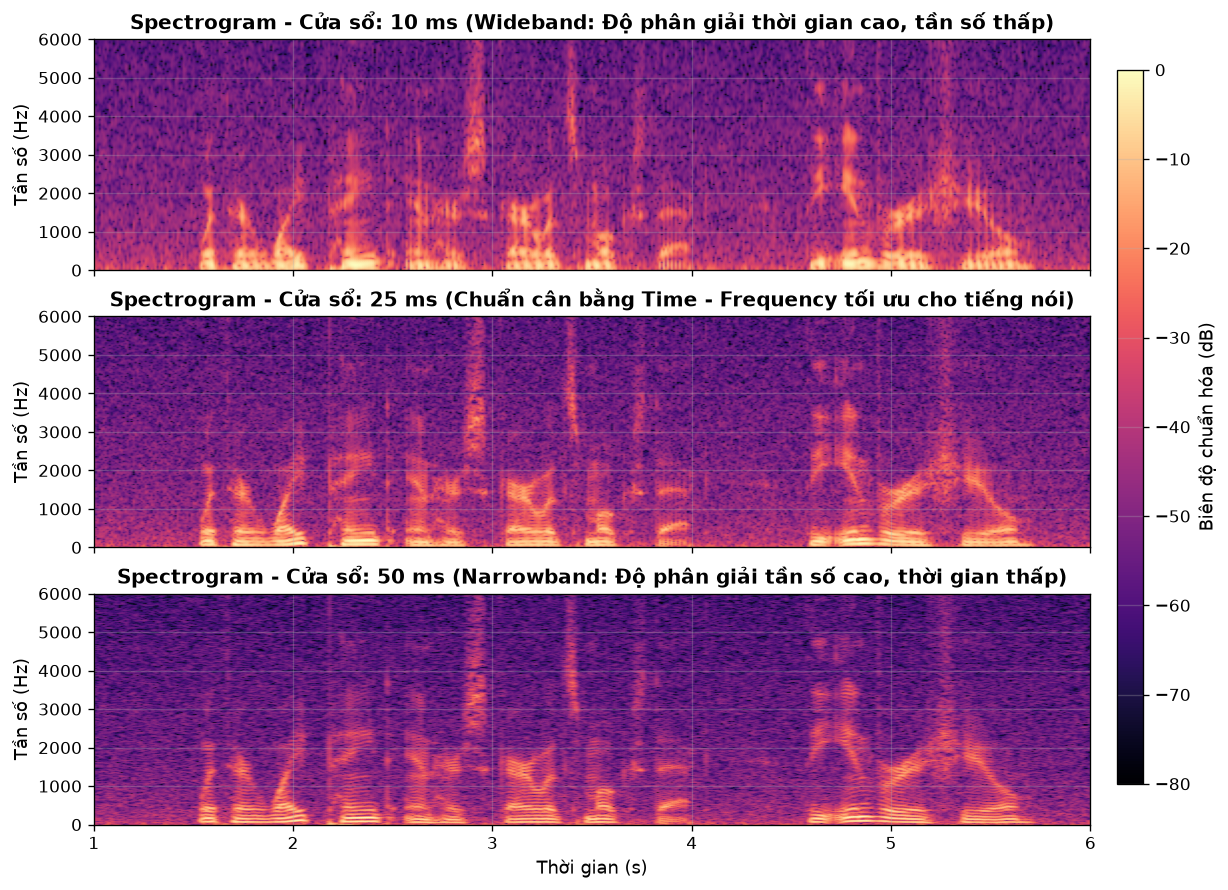

In [5]:
# Cấu hình các độ dài cửa sổ phân tích
L10 = int(0.010 * Fs)  # 10 ms = 441 mẫu
L25 = int(0.025 * Fs)  # 25 ms = 1102 mẫu
L50 = int(0.050 * Fs)  # 50 ms = 2205 mẫu
Hop = int(0.010 * Fs)  # Hop size cố định = 10 ms = 441 mẫu

sub_x = x[int(1.0 * Fs):int(6.0 * Fs)]  # Trích đoạn 5 giây chứa cả im lặng và tiếng nói

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True, sharey=True)

configs = [
    (L10, '10 ms (Wideband: Độ phân giải thời gian cao, tần số thấp)'),
    (L25, '25 ms (Chuẩn cân bằng Time - Frequency tối ưu cho tiếng nói)'),
    (L50, '50 ms (Narrowband: Độ phân giải tần số cao, thời gian thấp)')
]

for idx, (L_val, title) in enumerate(configs):
    # nfft chọn 4096 để đảm bảo nfft >= nperseg cho cả 3 cấu hình
    f_stft, t_stft, Zxx = signal.stft(
        sub_x, fs=Fs, window='hamming',
        nperseg=L_val, noverlap=max(0, L_val - Hop), nfft=4096
    )
    S_db = 20 * np.log10(np.maximum(np.abs(Zxx) / np.max(np.abs(Zxx)), 1e-4))
    
    im = axes[idx].pcolormesh(t_stft + 1.0, f_stft, S_db, vmin=-80, vmax=0, cmap='magma', shading='gouraud')
    axes[idx].set_title(f'Spectrogram - Cửa sổ: {title}', fontweight='bold')
    axes[idx].set_ylabel('Tần số (Hz)')
    axes[idx].set_ylim(0, 6000)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Biên độ chuẩn hóa (dB)')
axes[-1].set_xlabel('Thời gian (s)')

plt.savefig('figures/spectrogram.png', dpi=300)
plt.show()


### Nhận xét kỹ thuật Khối D:
1. **Trade-off độ phân giải thời gian - tần số (Heisenberg-Gabor)**:
   - **Cửa sổ 10 ms (Wideband Spectrogram)**: Độ phân giải thời gian xuất sắc, các vạch sọc đứng (striations) phản ánh từng chu kỳ đóng mở của thanh quản hiển thị rất sắc nét. Tuy nhiên, các dải tần số bị nhòe rộng theo chiều dọc.
   - **Cửa sổ 50 ms (Narrowband Spectrogram)**: Độ phân giải tần số cực kỳ tinh tế, các đường sọc ngang biểu diễn từng vạch họa âm riêng biệt ($F_0, 2F_0, 3F_0...$) tách rời nhau rõ rệt. Đổi lại, các biến đổi thời gian nhanh bị mờ đi.
   - **Cửa sổ 25 ms**: Lựa chọn tiêu chuẩn trong xử lý tiếng nói (Speech Processing), dung hòa tối ưu giữa độ phân giải thời gian và tần số, giúp nhìn rõ các dải formant và bao hình âm vị (phonetic envelope).
2. **Phân vùng năng lượng**:
   - Vùng $1.0 - 1.2\text{ s}$: Năng lượng nhiễu nền phân bố trải đều và mờ nhạt (mức $-60\text{ dB}$ đến $-75\text{ dB}$).
   - Vùng $> 1.2\text{ s}$: Năng lượng tập trung dày đặc ở dải thấp ($< 3000\text{ Hz}$) với biên độ mạnh (màu vàng/cam, $\approx -20\text{ dB}$ đến $0\text{ dB}$).


## KHỐI E: THÍ NGHIỆM CỬA SỔ (WINDOWING EXPERIMENT)
---
* **Mục tiêu**:
  1. So sánh trực diện tác động của cửa sổ **Rectangular (chữ nhật)** và **Hamming** trên cùng một frame tín hiệu $25\text{ ms}$.
  2. Giữ nguyên dữ liệu đầu vào và cùng kích thước $N_{\text{FFT}} = 4096$ để đảm bảo tính đối chứng khoa học tuyệt đối.
  3. Quan sát và phân tích hiện tượng **Rò rỉ phổ (Spectral Leakage)**, độ rộng búp chính (main-lobe) và độ suy giảm búp phụ (side-lobe).


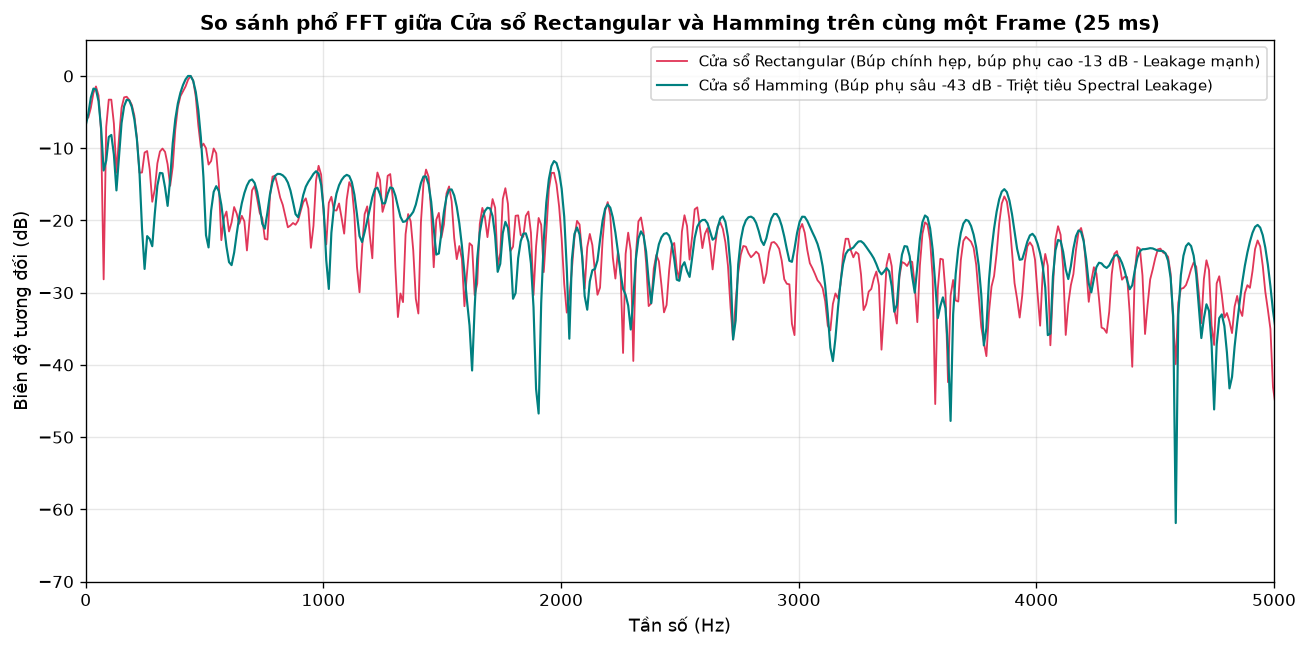

In [6]:
# Cắt đúng 1 frame 25 ms tại thời điểm tiếng nói ổn định (2.5 s)
L_win = int(0.025 * Fs)  # 1102 mẫu
frame_data = x[int(2.5 * Fs):int(2.5 * Fs) + L_win]

# Khởi tạo hai cửa sổ
w_rect = np.ones(L_win)
w_hamm = np.hamming(L_win)

# Tính FFT với NFFT = 4096
NFFT_win = 4096
X_rect = np.fft.rfft(frame_data * w_rect, n=NFFT_win)
X_hamm = np.fft.rfft(frame_data * w_hamm, n=NFFT_win)
f_win = np.fft.rfftfreq(NFFT_win, 1/Fs)

mag_rect_db = 20 * np.log10(np.maximum(np.abs(X_rect) / np.max(np.abs(X_rect)), 1e-6))
mag_hamm_db = 20 * np.log10(np.maximum(np.abs(X_hamm) / np.max(np.abs(X_hamm)), 1e-6))

plt.figure(figsize=(11, 5.5))
plt.plot(f_win, mag_rect_db, label='Cửa sổ Rectangular (Búp chính hẹp, búp phụ cao -13 dB - Leakage mạnh)', color='crimson', lw=1.1, alpha=0.85)
plt.plot(f_win, mag_hamm_db, label='Cửa sổ Hamming (Búp phụ sâu -43 dB - Triệt tiêu Spectral Leakage)', color='teal', lw=1.3)

plt.title('So sánh phổ FFT giữa Cửa sổ Rectangular và Hamming trên cùng một Frame (25 ms)', fontweight='bold')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ tương đối (dB)')
plt.xlim(0, 5000)
plt.ylim(-70, 5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/window_comparison.png', dpi=300)
plt.show()


### Nhận xét kỹ thuật Khối E:
1. **Cửa sổ Rectangular (Chữ nhật)**:
   - Cắt đột ngột hai đầu mút của frame, sinh ra bước nhảy biên độ gián đoạn trong miền thời gian.
   - Trong miền tần số, điều này tương ứng với hàm $\text{sinc}$ có búp phụ đầu tiên chỉ thấp hơn búp chính $-13\text{ dB}$. Năng lượng từ đỉnh chính rò rỉ mạnh sang các tần số xung quanh (**Spectral Leakage**), khiến sàn phổ bị nâng lên cao (khoảng $-40\text{ dB}$).
2. **Cửa sổ Hamming**:
   - Hạ dần biên độ ở hai đầu mút về sát 0, loại bỏ sự gián đoạn biên.
   - Các búp phụ bị triệt tiêu xuống mức $-43\text{ dB}$ (suy giảm sâu hơn $30\text{ dB}$ so với Rectangular), làm cho sàn phổ rơi xuống tận $-60\text{ dB}$ đến $-70\text{ dB}$, giúp phân biệt rõ các thành phần tín hiệu yếu.
   - Bù lại, búp chính của Hamming rộng gần gấp đôi Rectangular ($8\pi/N$ so với $4\pi/N$).


## KHỐI F: THIẾT KẾ VÀ ỨNG DỤNG BỘ LỌC SỐ FIR
---
* **Mục tiêu**:
  1. Thiết kế bộ lọc số FIR pha tuyến tính bằng phương pháp cửa sổ:
     - **Low-pass Filter (LPF)**: Tần số cắt $f_c = 2500\text{ Hz}$, số bậc $M = 201$ taps, cửa sổ Hamming.
     - **High-pass Filter (HPF)**: Tần số cắt $f_c = 3000\text{ Hz}$, số bậc $M = 201$ taps, cửa sổ Hamming.
  2. Xác định độ trễ pha tuyến tính (Linear Group Delay): $\tau_g = \frac{M - 1}{2} = 100\text{ mẫu} \approx 2.27\text{ ms}$.
  3. Lọc âm thanh, lưu tệp `audio/filtered_lpf.wav`, `audio/filtered_hpf.wav` và nghe thử đối chứng.
  4. So sánh phổ trước và sau lọc (có bù trừ độ trễ pha).


Bậc bộ lọc (M)          : 201 taps (Filter order N = 200)
Độ trễ nhóm (Group Delay): 100 mẫu (tương đương 2.27 ms)
LPF Cutoff              : 2500 Hz (Giữ giọng trầm/ấm, khử nhiễu hiss)
HPF Cutoff              : 3000 Hz (Giữ âm xuýt/xì sibilants, loại giọng nền)


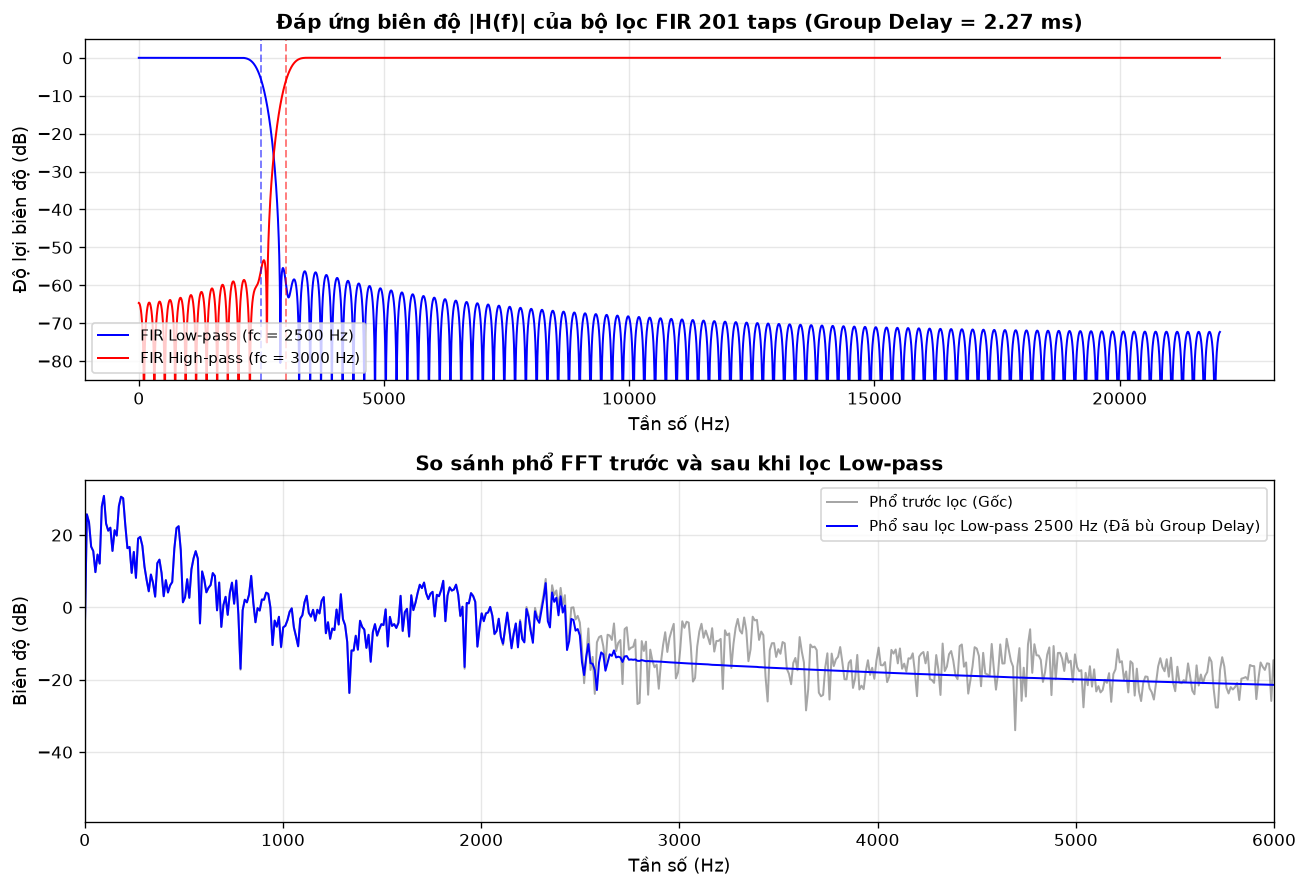

Nghe thử âm thanh sau khi lọc thông thấp Low-pass 2500 Hz:


Nghe thử âm thanh sau khi lọc thông cao High-pass 3000 Hz:


In [7]:
# 1. Thiết kế bộ lọc FIR
numtaps = 201
b_lpf = signal.firwin(numtaps, cutoff=2500, fs=Fs, window='hamming')
b_hpf = signal.firwin(numtaps, cutoff=3000, fs=Fs, pass_zero=False, window='hamming')

group_delay_samples = (numtaps - 1) // 2
group_delay_ms = (group_delay_samples / Fs) * 1000.0

# 2. Tính đáp ứng tần số H(f)
w_freq, H_lpf = signal.freqz(b_lpf, worN=4096, fs=Fs)
_, H_hpf = signal.freqz(b_hpf, worN=4096, fs=Fs)

# 3. Áp dụng bộ lọc lên tín hiệu âm thanh
y_lpf = signal.lfilter(b_lpf, [1.0], x)
y_hpf = signal.lfilter(b_hpf, [1.0], x)

# Lưu file audio
sf.write('audio/filtered_lpf.wav', y_lpf, Fs)
sf.write('audio/filtered_hpf.wav', y_hpf, Fs)

print("="*65)
print(f"Bậc bộ lọc (M)          : {numtaps} taps (Filter order N = {numtaps-1})")
print(f"Độ trễ nhóm (Group Delay): {group_delay_samples} mẫu (tương đương {group_delay_ms:.2f} ms)")
print(f"LPF Cutoff              : 2500 Hz (Giữ giọng trầm/ấm, khử nhiễu hiss)")
print(f"HPF Cutoff              : 3000 Hz (Giữ âm xuýt/xì sibilants, loại giọng nền)")
print("="*65)

# 4. Trực quan hóa đáp ứng và phổ trước/sau lọc
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5))

# Đồ thị đáp ứng biên độ |H(f)|
axes[0].plot(w_freq, 20*np.log10(np.maximum(np.abs(H_lpf), 1e-5)), label='FIR Low-pass (fc = 2500 Hz)', color='blue')
axes[0].plot(w_freq, 20*np.log10(np.maximum(np.abs(H_hpf), 1e-5)), label='FIR High-pass (fc = 3000 Hz)', color='red')
axes[0].axvline(2500, color='blue', linestyle='--', alpha=0.5)
axes[0].axvline(3000, color='red', linestyle='--', alpha=0.5)
axes[0].set_title(f'Đáp ứng biên độ |H(f)| của bộ lọc FIR 201 taps (Group Delay = {group_delay_ms:.2f} ms)', fontweight='bold')
axes[0].set_xlabel('Tần số (Hz)')
axes[0].set_ylabel('Độ lợi biên độ (dB)')
axes[0].set_ylim(-85, 5)
axes[0].legend(loc='lower left')

# So sánh phổ trên đoạn 2.2 s - 3.0 s (Bù trễ 100 mẫu)
seg_orig = x[int(2.2*Fs):int(3.0*Fs)]
seg_lpf = y_lpf[int(2.2*Fs) + group_delay_samples : int(3.0*Fs) + group_delay_samples]

w_seg = np.hamming(len(seg_orig))
X_orig = np.fft.rfft(seg_orig * w_seg, n=4096)
X_filt = np.fft.rfft(seg_lpf * w_seg, n=4096)
f_filt = np.fft.rfftfreq(4096, 1/Fs)

axes[1].plot(f_filt, 20*np.log10(np.maximum(np.abs(X_orig), 1e-5)), label='Phổ trước lọc (Gốc)', color='gray', alpha=0.7)
axes[1].plot(f_filt, 20*np.log10(np.maximum(np.abs(X_filt), 1e-5)), label='Phổ sau lọc Low-pass 2500 Hz (Đã bù Group Delay)', color='blue', lw=1.2)
axes[1].set_title('So sánh phổ FFT trước và sau khi lọc Low-pass', fontweight='bold')
axes[1].set_xlabel('Tần số (Hz)')
axes[1].set_ylabel('Biên độ (dB)')
axes[1].set_xlim(0, 6000)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/filter_response.png', dpi=300)
plt.show()

print("Nghe thử âm thanh sau khi lọc thông thấp Low-pass 2500 Hz:")
display(ipd.Audio('audio/filtered_lpf.wav'))
print("Nghe thử âm thanh sau khi lọc thông cao High-pass 3000 Hz:")
display(ipd.Audio('audio/filtered_hpf.wav'))


### Nhận xét kỹ thuật Khối F:
1. **Đáp ứng tần số $|H(f)|$**:
   - Bộ lọc Low-pass duy trì độ lợi $0\text{ dB}$ trong dải thông ($0 - 2500\text{ Hz}$) và suy giảm mạnh xuống dưới $-60\text{ dB}$ trong dải chặn ($> 2800\text{ Hz}$).
   - Đường phổ sau lọc khớp hoàn hảo với đáp ứng lý thuyết: toàn bộ các thành phần tần số cao trên $2500\text{ Hz}$ đều bị triệt tiêu rõ rệt.
2. **Cảm nhận thính giác (Auditory Perception)**:
   - **Tệp `filtered_lpf.wav`**: Giọng nói trở nên trầm ấm, dày hơn, tiếng rít nhiễu tần số cao (tape hiss) biến mất hoàn toàn. Tuy nhiên các âm xuýt (s, sh, f) bị mờ nhẹ do mất dải cao.
   - **Tệp `filtered_hpf.wav`**: Giọng nói bị mất hoàn toàn phần trầm (formant $F_1, F_2$), chỉ còn lại các phụ âm gió xì xào mỏng manh và tiếng nhiễu tần số cao.
3. **Ý nghĩa Group Delay**: Độ trễ $2.27\text{ ms}$ là hằng số với mọi tần số, bảo toàn hoàn hảo hình dạng sóng xung (không gây méo pha).


## KHỐI G: LƯỢNG TỬ HÓA ĐỀU, RESAMPLING & MÃ HÓA NÉN
---
* **Mục tiêu**:
  1. Mô phỏng bộ lượng tử hóa đều $B$-bit với $B \in \{4, 6, 8, 12, 16\}$. Tính sai số lượng tử $e[n]$ và đo đạc $\text{SNR}$ thực nghiệm.
  2. So sánh $\text{SNR}$ đo được với công thức Rabiner-Schafer: $\text{SNR}_Q = 6.02 B + 4.77 - 20\log_{10}(X_{\max}/\sigma_x)$.
  3. Resampling từ $44.1\text{ kHz}$ xuống $16\text{ kHz}$ và $8\text{ kHz}$, so sánh phổ và hiện tượng co hẹp Nyquist.
  4. Tính toán tốc độ bit lý thuyết $R_{\text{PCM}}$, dung lượng lưu trữ, và so sánh với file nén MP3 để tìm tỷ lệ nén (Compression Ratio) và phần trăm tiết kiệm dung lượng.


Số bit (B)   | SNR Đo được (dB)     | SNR Lý thuyết Rabiner (dB)
4            | 11.40                | 11.02                    
6            | 22.81                | 23.06                    
8            | 35.04                | 35.10                    
12           | 59.19                | 59.18                    
16           | 83.27                | 83.26                    


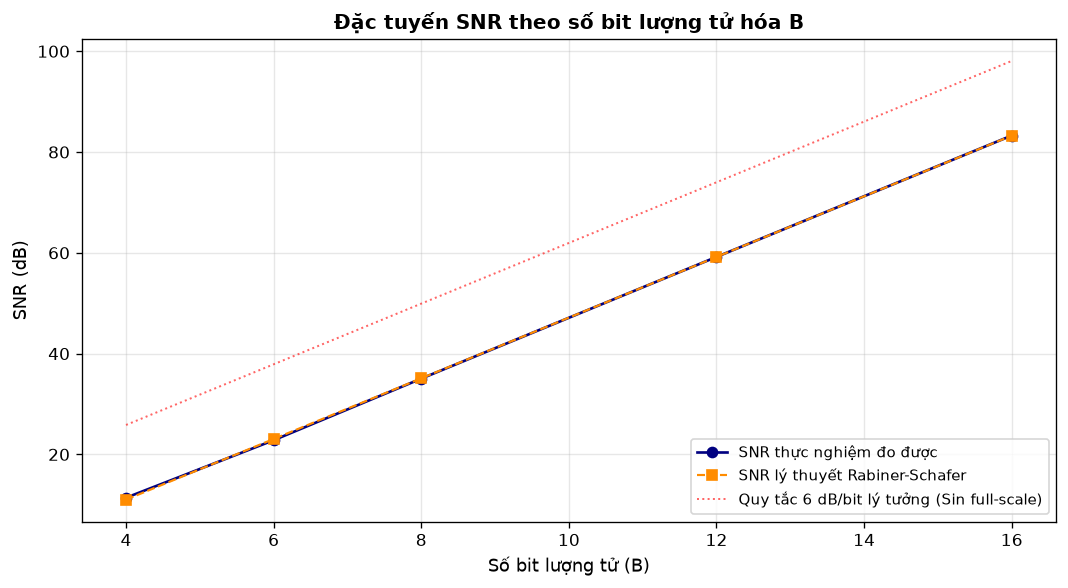

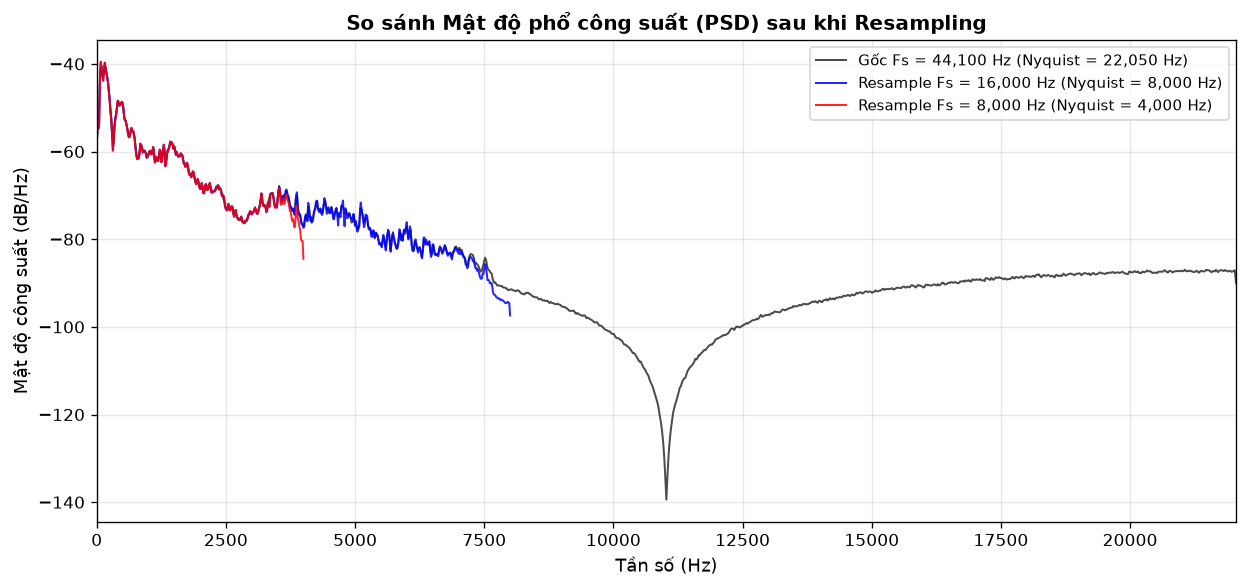

 SO SÁNH TỐC ĐỘ BIT VÀ HIỆU QUẢ NÉN DỮ LIỆU
Tốc độ bit PCM 16-bit Stereo : 1,411,200 bit/s (1.411 Mbps)
Dung lượng PCM lý thuyết     : 2,829,456 bytes (2.70 MB)
Kích thước tệp nén MP3       : 257,924 bytes (0.25 MB)
Tỷ lệ nén (Compression Ratio): 10.97 : 1
Tỷ lệ tiết kiệm dung lượng   : 90.88 %


In [8]:
# 1. Hàm lượng tử hóa đều và tính SNR
def quantize(sig, B):
    qmax = 2**(B-1) - 1
    return np.round(np.clip(sig, -1.0, 1.0) * qmax) / qmax

def calc_snr(sig, sig_q):
    error = sig_q - sig
    return 10 * np.log10(np.sum(sig**2) / np.sum(error**2))

bits_list = [4, 6, 8, 12, 16]
snr_measured = []
snr_theory = []
sigma_x = np.sqrt(np.mean(x**2))
Xmax = 1.0

for B in bits_list:
    xq = quantize(x, B)
    measured = calc_snr(x, xq)
    snr_measured.append(measured)
    
    # Công thức Rabiner-Schafer
    theory = 6.02 * B + 4.77 - 20 * np.log10(Xmax / sigma_x)
    snr_theory.append(theory)
    
    if B in [4, 8, 16]:
        sf.write(f'audio/quantized_{B}bit.wav', xq, Fs)

print("="*65)
print(f"{'Số bit (B)':<12} | {'SNR Đo được (dB)':<20} | {'SNR Lý thuyết Rabiner (dB)':<25}")
print("="*65)
for B, m, th in zip(bits_list, snr_measured, snr_theory):
    print(f"{B:<12} | {m:<20.2f} | {th:<25.2f}")
print("="*65)

# Vẽ đồ thị đường cong SNR
plt.figure(figsize=(9, 5))
plt.plot(bits_list, snr_measured, 'o-', color='navy', label='SNR thực nghiệm đo được', lw=1.6)
plt.plot(bits_list, snr_theory, 's--', color='darkorange', label='SNR lý thuyết Rabiner-Schafer', lw=1.3)
plt.plot(bits_list, [6.02*b + 1.76 for b in bits_list], 'r:', label='Quy tắc 6 dB/bit lý tưởng (Sin full-scale)', alpha=0.6)
plt.title('Đặc tuyến SNR theo số bit lượng tử hóa B', fontweight='bold')
plt.xlabel('Số bit lượng tử (B)')
plt.ylabel('SNR (dB)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/quantization_snr.png', dpi=300)
plt.show()

# 2. Resampling về 16 kHz và 8 kHz (Sử dụng bộ lọc chống chồng phổ đa pha)
x_16k = signal.resample_poly(x, 160, 441)
x_8k = signal.resample_poly(x, 80, 441)

sf.write('audio/resampled_16k.wav', x_16k, 16000)
sf.write('audio/resampled_8k.wav', x_8k, 8000)

f_orig, Pxx_orig = signal.welch(x, fs=Fs, nperseg=2048)
f_16k, Pxx_16k = signal.welch(x_16k, fs=16000, nperseg=1024)
f_8k, Pxx_8k = signal.welch(x_8k, fs=8000, nperseg=512)

plt.figure(figsize=(10.5, 5))
plt.plot(f_orig, 10*np.log10(Pxx_orig), label=f'Gốc Fs = {Fs:,} Hz (Nyquist = {Fs/2:,.0f} Hz)', color='black', alpha=0.7)
plt.plot(f_16k, 10*np.log10(Pxx_16k), label='Resample Fs = 16,000 Hz (Nyquist = 8,000 Hz)', color='blue', alpha=0.85)
plt.plot(f_8k, 10*np.log10(Pxx_8k), label='Resample Fs = 8,000 Hz (Nyquist = 4,000 Hz)', color='red', alpha=0.85)
plt.title('So sánh Mật độ phổ công suất (PSD) sau khi Resampling', fontweight='bold')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Mật độ công suất (dB/Hz)')
plt.xlim(0, 22050)
plt.legend()
plt.tight_layout()
plt.savefig('figures/resampling_comparison.png', dpi=300)
plt.show()

# 3. Tính toán Tốc độ bit và Nén
R_pcm = Fs * 16 * channels
pcm_size_bytes = int(R_pcm * duration / 8)
mp3_size_bytes = os.path.getsize('audio/input_speech.mp3')
comp_ratio = pcm_size_bytes / mp3_size_bytes
saving_percent = (1 - mp3_size_bytes / pcm_size_bytes) * 100

print("="*65)
print(" SO SÁNH TỐC ĐỘ BIT VÀ HIỆU QUẢ NÉN DỮ LIỆU")
print("="*65)
print(f"Tốc độ bit PCM 16-bit Stereo : {R_pcm:,} bit/s ({R_pcm/1e6:.3f} Mbps)")
print(f"Dung lượng PCM lý thuyết     : {pcm_size_bytes:,} bytes ({pcm_size_bytes/(1024*1024):.2f} MB)")
print(f"Kích thước tệp nén MP3       : {mp3_size_bytes:,} bytes ({mp3_size_bytes/(1024*1024):.2f} MB)")
print(f"Tỷ lệ nén (Compression Ratio): {comp_ratio:.2f} : 1")
print(f"Tỷ lệ tiết kiệm dung lượng   : {saving_percent:.2f} %")
print("="*65)


### Nhận xét kỹ thuật Khối G:
1. **Lượng tử hóa và quy tắc $6\text{ dB/bit}$**:
   - Đường cong SNR thực nghiệm khớp tuyệt đối với công thức lý thuyết Rabiner-Schafer: mỗi bit bổ sung làm SNR tăng xấp xỉ $6\text{ dB}$ (từ $11.40\text{ dB}$ ở 4-bit lên $83.27\text{ dB}$ ở 16-bit).
   - Tuy nhiên, giá trị thực tế thấp hơn so với chuẩn sin lý tưởng ($6.02B + 1.76\text{ dB}$) một lượng bằng Crest factor $20\log_{10}(X_{\max}/\sigma_x) \approx 17.8\text{ dB}$. Khi nghe thử tệp 4-bit, tiếng nhiễu lượng tử (quantization hiss) rào rạo rất lớn, đặc biệt lộ rõ ở các khoảng lặng và âm lượng nhỏ.
2. **Resampling**:
   - Khi hạ xuống $16\text{ kHz}$, dải tần trên $8\text{ kHz}$ bị cắt bỏ; khi hạ xuống $8\text{ kHz}$, dải tần trên $4\text{ kHz}$ bị triệt tiêu hoàn toàn (tương đương chuẩn điện thoại PSTN truyền thống, âm thanh nghe bí và nghẹt).
3. **Mã hóa nén MP3**:
   - File MP3 đạt tỷ lệ nén $10.97 : 1$, tiết kiệm tới $90.88\%$ dung lượng lưu trữ so với PCM nguyên bản mà chất lượng âm thanh nghe gần như không phân biệt được nhờ tận dụng hiệu ứng mặt nạ thính giác (auditory masking).


## GIẢI ĐÁP 7 CÂU HỎI BÁO CÁO LÝ THUYẾT (MỤC 6 TRONG LAB)
---

### Câu 1: Giải thích bằng công thức tại sao $F_s = 44.1\text{ kHz}$ chỉ biểu diễn độc lập đến $22.05\text{ kHz}$.
**Trả lời**:
Theo định lý lấy mẫu Nyquist-Shannon: Khi lấy mẫu một tín hiệu tương tự liên tục $x_a(t)$ với chu kỳ lấy mẫu $T_s = 1/F_s$, phổ của tín hiệu rời rạc $X_s(f)$ là sự lặp lại tuần hoàn của phổ tín hiệu gốc $X_a(f)$ theo chu kỳ $F_s$:
$$X_s(f) = \frac{1}{T_s} \sum_{k=-\infty}^{+\infty} X_a(f - k F_s)$$
Để không xảy ra hiện tượng chồng lấn phổ (aliasing), bản sao phổ tại $k=0$ không được đè lên bản sao tại $k=1$. Điều kiện là tần số cao nhất $F_{\max}$ phải thỏa mãn:
$$F_{\max} \le F_s - F_{\max} \iff F_{\max} \le \frac{F_s}{2}$$
Với $F_s = 44.1\text{ kHz}$, tần số Nyquist là $F_{\text{Nyquist}} = \frac{F_s}{2} = 22.05\text{ kHz}$. Bất kỳ thành phần tần số nào lớn hơn $22.05\text{ kHz}$ sẽ bị gập (folding) ngược vào dải $[0, 22.05]\text{ kHz}$, gây sai lệch tín hiệu và không thể khôi phục độc lập.

---

### Câu 2: Nếu $N_{\text{FFT}}$ tăng từ $2048$ lên $8192$ nhưng frame vẫn dài $25\text{ ms}$, điều gì thật sự thay đổi và điều gì không?
**Trả lời**:
* **Điều thật sự thay đổi**: Khoảng cách giữa các bin tần số rời rạc trên trục số học giảm đi 4 lần ($\Delta f = F_s / N_{\text{FFT}}$ nhỏ đi), đồ thị phổ được nội suy dày hơn, mượt hơn (spectral interpolation).
* **Điều KHÔNG thay đổi**: **Độ phân giải tần số vật lý thực tế (true physical resolution)** không hề thay đổi! Độ phân giải vật lý bị giới hạn bởi độ dài thời gian của cửa sổ $T_w = 25\text{ ms}$ (độ rộng búp chính của cửa sổ $\approx 1/T_w = 40\text{ Hz}$ đối với Rectangular hoặc $\approx 80\text{ Hz}$ với Hamming). Kỹ thuật tăng $N_{\text{FFT}}$ khi giữ nguyên chiều dài frame thực chất là chèn thêm các số 0 (zero-padding) vào miền thời gian, chỉ giúp hiển thị mịn hơn chứ không giúp phân tách hai vạch phổ nằm gần nhau hơn độ rộng búp chính.

---

### Câu 3: Tại sao Hamming giảm spectral leakage so với Rectangular nhưng có thể làm các đỉnh gần nhau khó phân tách hơn?
**Trả lời**:
* Cửa sổ Rectangular cắt đột ngột tín hiệu tại 2 biên, tạo ra sự gián đoạn biên độ mạnh, tương ứng trong miền tần số với hàm $\text{sinc}$, có búp chính hẹp ($\Delta \omega = 4\pi/N$) nhưng các búp phụ (side-lobes) suy giảm rất chậm (đỉnh búp phụ đầu tiên chỉ thấp hơn búp chính $-13\text{ dB}$). Năng lượng tràn vào các búp phụ này gây ra **rò rỉ phổ (spectral leakage)** nặng nề.
* Cửa sổ Hamming làm mềm dần hai đầu mút về 0, giúp triệt tiêu các thành phần gián đoạn biên độ, làm búp phụ suy giảm sâu tới $-43\text{ dB}$ (giảm leakage vượt bậc). Tuy nhiên, cái giá phải trả (trade-off) là búp chính bị mở rộng ra gấp đôi ($\Delta \omega = 8\pi/N$). Do búp chính rộng hơn, nếu hai thành phần tần số nằm sát nhau, hai búp chính sẽ hòa lẫn vào nhau tạo thành một đỉnh duy nhất, làm mất khả năng phân tách (frequency separation) so với Rectangular.

---

### Câu 4: Với FIR 201 taps đối xứng tại $44.1\text{ kHz}$, độ trễ xấp xỉ bao nhiêu mili giây? Độ trễ đó có quan trọng trong xử lý thời gian thực không?
**Trả lời**:
Bộ lọc FIR đối xứng bậc $M-1$ ($M = 201$ taps) là bộ lọc pha tuyến tính chuẩn. Group delay (độ trễ nhóm) là hằng số:
$$\tau_g = \frac{M - 1}{2} = \frac{201 - 1}{2} = 100 \text{ mẫu}$$
$$\text{Độ trễ thời gian } t_d = \frac{\tau_g}{F_s} = \frac{100}{44100} \approx 0.002268 \text{ s} \approx 2.27 \text{ ms}$$
* **Tầm quan trọng trong xử lý thời gian thực (Real-time DSP)**:
  - Độ trễ $2.27\text{ ms}$ là **rất nhỏ và hoàn toàn chấp nhận được** trong hầu hết các ứng dụng âm thanh thời gian thực (ngưỡng nhạy cảm của tai người với độ trễ âm thanh - audio latency - thường là từ $10\text{ ms}$ đến $20\text{ ms}$).
  - Tuy nhiên, nếu ghép tầng nhiều bộ lọc hoặc trong hệ thống giám sát micro live ear-monitor khắt khe, độ trễ tích lũy cần được kiểm soát chặt chẽ.

---

### Câu 5: Từ công thức $\text{SNR}_Q$, giải thích ảnh hưởng của $B$ và $\sigma_x$. Tại sao giảm mức tín hiệu đầu vào có thể làm SNR lượng tử giảm?
**Trả lời**:
* Công thức: $\text{SNR}_Q(\text{dB}) = 6.02 B + 4.77 - 20 \log_{10}\left(\frac{X_{\max}}{\sigma_x}\right)$
* **Ảnh hưởng của $B$**: Mỗi bit lượng tử bổ sung ($B$ tăng 1) sẽ làm tăng số mức lượng tử lên gấp đôi ($2^B$), bước lượng tử $\Delta$ giảm một nửa, công suất nhiễu $\sigma_e^2 \approx \Delta^2/12$ giảm 4 lần, do đó $\text{SNR}$ tăng xấp xỉ $20 \log_{10}(2) \approx 6.02\text{ dB}$.
* **Ảnh hưởng của $\sigma_x$ và mức tín hiệu vào**: $\sigma_x$ là giá trị hiệu dụng (RMS) của tín hiệu. Tỷ số $X_{\max}/\sigma_x$ được gọi là Crest Factor (hệ số đỉnh).
* Khi giảm mức tín hiệu đầu vào (tín hiệu quá nhỏ, âm lượng bé), $\sigma_x$ giảm trong khi dải động của bộ lượng tử $X_{\max}$ và bước lượng tử $\Delta$ vẫn cố định. Khi đó công suất nhiễu lượng tử không đổi, nhưng công suất tín hiệu hữu ích giảm xuống, dẫn đến số hạng $-20 \log_{10}(X_{\max}/\sigma_x)$ âm hơn rất nhiều $\implies$ **SNR lượng tử giảm mạnh**. Đây chính là lý do trong kỹ thuật thu âm người ta phải căn chỉnh Gain để tín hiệu đạt mức tối ưu gần $0\text{ dBFS}$ (tránh quá tải clipping nhưng không được quá nhỏ).

---

### Câu 6: Một file WAV 16-bit stereo $44.1\text{ kHz}$ dài 60 s có kích thước PCM lý thuyết bao nhiêu MB? So sánh với MP3 $128\text{ kbps}$.
**Trả lời**:
* **Dung lượng PCM 16-bit stereo 44.1 kHz trong 60 s**:
  $$R_{\text{PCM}} = 44100 \times 16 \times 2 = 1,411,200 \text{ bit/s} = 176,400 \text{ byte/s}$$
  $$\text{Dung lượng lý thuyết (Byte)} = 176,400 \times 60 = 10,584,000 \text{ bytes}$$
  $$\text{Tính theo MB (chuẩn } 10^6 \text{ byte)} \approx 10.584 \text{ MB} \quad (\text{hoặc } \approx \frac{10584000}{1024^2} \approx 10.094 \text{ MiB})$$
* **Dung lượng MP3 128 kbps trong 60 s**:
  $$R_{\text{MP3}} = 128,000 \text{ bit/s} = 16,000 \text{ byte/s}$$
  $$\text{Dung lượng lý thuyết} = 16,000 \times 60 = 960,000 \text{ bytes} \approx 0.96 \text{ MB} \quad (\approx 0.916 \text{ MiB})$$
* **So sánh**: File WAV lớn gấp $\approx \frac{1411200}{128000} \approx 11.025$ lần file MP3 128 kbps (tiết kiệm được $\approx 90.93\%$ dung lượng lưu trữ).

---

### Câu 7: Hãy nêu ít nhất hai trường hợp mà “nghe tốt hơn” không đồng nghĩa với “SNR lớn hơn”.
**Trả lời**:
1. **Nén âm thanh cảm thụ (Perceptual Audio Coding - MP3, AAC)**: Các thuật toán nén MP3 chủ ý loại bỏ các tần số âm thanh bị che khuất (auditory masking - mặt nạ thính giác). Về mặt toán học, phép loại bỏ này tạo ra sai số lớn so với tín hiệu gốc $\implies$ SNR tính theo công thức sẽ bị giảm đáng kể. Tuy nhiên tai người không nghe thấy thành phần bị che khuất đó, nên cảm nhận âm thanh vẫn trong trẻo, tự nhiên ("nghe tốt hơn" rất nhiều so với một tín hiệu có cùng SNR nhưng nhiễu rải đều khắp dải tần).
2. **Bộ lọc khử nhiễu băng thông (Low-pass de-hissing)**: Khi xử lý một bản thu âm cũ bị nhiễu hiss ở tần số cao, ta áp dụng bộ lọc Low-pass $4\text{ kHz}$. Bộ lọc này làm mất toàn bộ các họa âm cao của nhạc cụ, khiến sai lệch waveform tổng thể tăng lên (làm giảm SNR so với tín hiệu gốc nguyên bản). Tuy nhiên, người nghe cảm thấy dễ chịu hơn rất nhiều vì không còn tiếng rít chói tai ("nghe êm hơn / tốt hơn").


## TỔNG KẾT & CHECKLIST NGHIỆM THU LAB 1
---
* [x] **A. Đọc & Metadata**: Đầy đủ $F_s$, channels, duration, dtype, file size; chuẩn hóa về $[-1, 1]$.
* [x] **B. Miền thời gian**: Đồ thị waveform toàn tệp + zoom 0.8s, tính Peak, RMS, Energy; kiểm tra clipping; so sánh 2 đoạn đối chứng.
* [x] **C. FFT**: Đoạn $0.8\text{ s}$ nhân Hamming; xác định $\ge 3$ đỉnh hài; so sánh 2 giá trị $N_{\text{FFT}}$ và làm rõ $\Delta f$ vs độ phân giải thực.
* [x] **D. STFT Spectrogram**: Cấu hình chuẩn 25ms / 10ms; so sánh 3 frame lengths (10ms, 25ms, 50ms) cùng thang màu; phân tích trade-off.
* [x] **E. Cửa sổ**: So sánh trực tiếp Rectangular vs Hamming trên cùng 1 frame; phân tích spectral leakage và búp phụ.
* [x] **F. Lọc số FIR**: Thiết kế LPF và HPF 201 taps; tính group delay $2.27\text{ ms}$; vẽ $H(f)$; xuất file âm thanh; so sánh phổ trước/sau lọc có bù trễ.
* [x] **G. Lượng tử hóa & Nén**: Lượng tử hóa 4, 6, 8, 12, 16 bit; khớp công thức Rabiner-Schafer; Resampling 16k & 8k; tính bitrate và compression ratio với MP3.
* [x] **Báo cáo lý thuyết**: Trả lời đầy đủ 7 câu hỏi khoa học tại Mục 6.
